# Práctica: p-values y Corrección de Bonferroni con **California Housing** (scikit-learn)

Este notebook:
1) Descarga/carga el dataset real **California Housing** usando `sklearn.datasets.fetch_california_housing`  
2) Plantea un problema y define *múltiples* hipótesis  
3) Calcula p-values (correlación de Pearson / tests t en regresión simple)  
4) Aplica **Bonferroni** y compara resultados  
5) Incluye ideas para conclusiones

> Requisitos: `scikit-learn`, `pandas`, `numpy` y **`scipy`** (para p-values).


In [4]:
import numpy as np
import pandas as pd

from sklearn.datasets import fetch_california_housing

# Configuración visual (opcional)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
np.random.seed(0)


## 1) Cargar el dataset (descarga automática)

`fetch_california_housing()` descarga el dataset la primera vez (y luego lo guarda en caché).


In [5]:
data = fetch_california_housing(as_frame=True)

# data.frame incluye features + target, y data.target es la variable objetivo
df = data.frame.copy()
df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### Variables
- **Target**: `MedHouseVal` (valor mediano de casas, en centenas de miles de USD)
- Features: `MedInc`, `HouseAge`, `AveRooms`, `AveBedrms`, `Population`, `AveOccup`, `Latitude`, `Longitude`


In [6]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


## 2) Planteamiento del problema

Ejemplo de planteamiento:

> **¿Qué variables del censo (ingreso, densidad, ubicación, etc.) están asociadas de forma significativa con el valor mediano de la vivienda?**

Esto nos permite hacer *múltiples pruebas* (una por variable).


## 3) Hipótesis y p-values

Vamos a probar (para cada feature `X`):

- **H0**: no hay relación lineal entre `X` y `MedHouseVal` (correlación poblacional ρ = 0)
- **H1**: sí hay relación lineal (ρ ≠ 0)

Calcularemos el p-value de la correlación de Pearson.

> Si tu profe prefiere otra prueba (Spearman / regresión / ANOVA), se puede adaptar.


In [7]:
# Intentamos usar scipy para p-values
try:
    from scipy import stats
except ImportError as e:
    raise ImportError(
        "Este notebook necesita scipy para calcular p-values. "
        "Instálalo con: pip install scipy"
    )

target = "MedHouseVal"
features = [c for c in df.columns if c != target]

results = []
for col in features:
    x = df[col].to_numpy()
    y = df[target].to_numpy()
    r, p = stats.pearsonr(x, y)
    results.append({"feature": col, "pearson_r": r, "p_value": p})

res = pd.DataFrame(results).sort_values("p_value")
res


,feature,pearson_r,p_value
0,MedInc,0.688075,0.000000e+00
2,AveRooms,0.151948,7.569242e-107
6,Latitude,-0.144160,2.939859e-96
1,HouseAge,0.105623,2.761861e-52
3,AveBedrms,-0.046701,1.912589e-11
7,Longitude,-0.045967,3.923322e-11
4,Population,-0.024650,3.976308e-04
5,AveOccup,-0.023737,6.483442e-04


## 4) Corrección de Bonferroni

Si hacemos **m** pruebas, Bonferroni controla el error tipo I familiar (FWER) usando:

- Umbral corregido: \( \alpha' = \alpha / m \)
- o p-values ajustados: \( p_{adj} = \min(p \cdot m, 1) \)

Usaremos ambos enfoques.


In [8]:
alpha = 0.05
m = len(res)

res = res.copy()
res["p_bonferroni"] = np.minimum(res["p_value"] * m, 1.0)
res["reject_H0_raw"] = res["p_value"] < alpha
res["reject_H0_bonf"] = res["p_value"] < (alpha / m)

alpha_bonf = alpha / m
alpha, m, alpha_bonf


(0.05, 8, 0.00625)

In [9]:
res


,feature,pearson_r,p_value,p_bonferroni,reject_H0_raw,reject_H0_bonf
0,MedInc,0.688075,0.000000e+00,0.000000e+00,True,True
2,AveRooms,0.151948,7.569242e-107,6.055394e-106,True,True
6,Latitude,-0.144160,2.939859e-96,2.351887e-95,True,True
1,HouseAge,0.105623,2.761861e-52,2.209489e-51,True,True
3,AveBedrms,-0.046701,1.912589e-11,1.530072e-10,True,True
7,Longitude,-0.045967,3.923322e-11,3.138658e-10,True,True
4,Population,-0.024650,3.976308e-04,3.181046e-03,True,True
5,AveOccup,-0.023737,6.483442e-04,5.186754e-03,True,True


### Comparación: significancia antes vs después


In [10]:
summary = pd.DataFrame({
    "alpha": [alpha],
    "m_tests": [m],
    "alpha_bonf": [alpha_bonf],
    "significant_raw_count": [int(res["reject_H0_raw"].sum())],
    "significant_bonf_count": [int(res["reject_H0_bonf"].sum())],
})
summary


,alpha,m_tests,alpha_bonf,significant_raw_count,significant_bonf_count
0,0.05,8,0.00625,8,8


## 5) Visual rápido (opcional)

Para ver por qué algunas relaciones son fuertes o débiles.


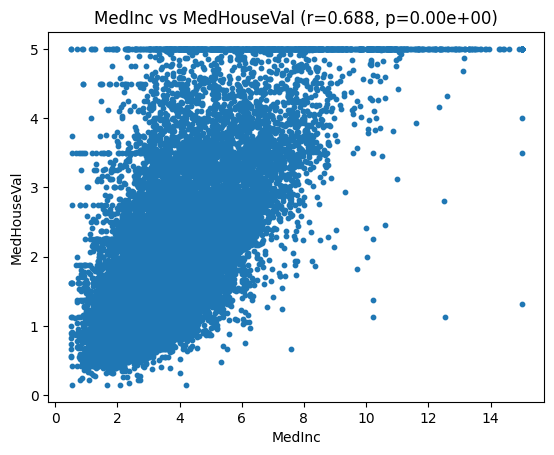

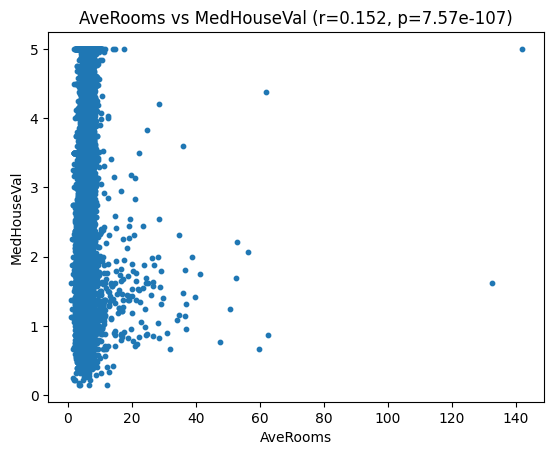

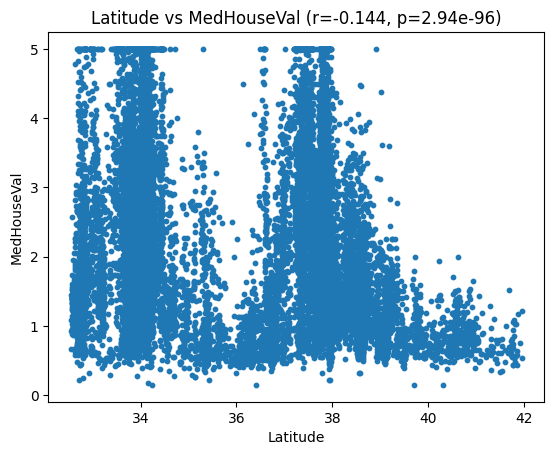

In [11]:
import matplotlib.pyplot as plt

# Top 3 asociaciones (por p-value) para graficar
top = res.head(3)["feature"].tolist()

for col in top:
    plt.figure()
    plt.scatter(df[col], df[target], s=10)
    plt.xlabel(col)
    plt.ylabel(target)
    r = float(res.loc[res["feature"] == col, "pearson_r"].iloc[0])
    p = float(res.loc[res["feature"] == col, "p_value"].iloc[0])
    plt.title(f"{col} vs {target} (r={r:.3f}, p={p:.2e})")
    plt.show()


## 6) (Opcional) Más pruebas para que Bonferroni “se note” más

Con solo 8 variables, **m=8**.  
Si quieres un escenario con más pruebas (más realista para Bonferroni), puedes crear:

### A) Pruebas por bins (discretizar y comparar grupos)
Ejemplo: dividir latitud/longitud en varios bins y probar diferencias.

### B) Interacciones
Crear variables de interacción (producto) y probar correlaciones contra el target.

Abajo se muestra una opción simple: **interacciones por pares**.


In [12]:
# Crear interacciones por pares (X_i * X_j) para incrementar el número de pruebas
# (Esto es solo para la práctica; en ciencia real habría que justificarlo)
interaction_results = []
cols = features

for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        name = f"{cols[i]}*{cols[j]}"
        x = (df[cols[i]] * df[cols[j]]).to_numpy()
        y = df[target].to_numpy()
        r, p = stats.pearsonr(x, y)
        interaction_results.append({"feature": name, "pearson_r": r, "p_value": p})

inter = pd.DataFrame(interaction_results).sort_values("p_value")
inter.head(10)


,feature,pearson_r,p_value
0,MedInc*HouseAge,0.589142,0.000000e+00
1,MedInc*AveRooms,0.555438,0.000000e+00
2,MedInc*AveBedrms,0.510058,0.000000e+00
3,MedInc*Population,0.276269,0.000000e+00
5,MedInc*Latitude,0.674713,0.000000e+00
6,MedInc*Longitude,-0.689376,0.000000e+00
7,HouseAge*AveRooms,0.210048,1.595809e-204
17,AveRooms*Longitude,-0.153274,1.044241e-108
16,AveRooms*Latitude,0.121177,2.321633e-68
12,HouseAge*Longitude,-0.107602,3.314634e-54


In [13]:
alpha = 0.05
m2 = len(inter)

inter = inter.copy()
inter["p_bonferroni"] = np.minimum(inter["p_value"] * m2, 1.0)
inter["reject_H0_raw"] = inter["p_value"] < alpha
inter["reject_H0_bonf"] = inter["p_value"] < (alpha / m2)

pd.DataFrame({
    "alpha": [alpha],
    "m_tests": [m2],
    "alpha_bonf": [alpha/m2],
    "significant_raw_count": [int(inter["reject_H0_raw"].sum())],
    "significant_bonf_count": [int(inter["reject_H0_bonf"].sum())],
})


,alpha,m_tests,alpha_bonf,significant_raw_count,significant_bonf_count
0,0.05,28,0.001786,24,23


## 7) Ideas para conclusiones (para tu reporte)

Incluye en tus conclusiones:

- **Antes de Bonferroni**: cuántas variables/interacciones parecían “significativas” (p < 0.05).
- **Después de Bonferroni**: cuántas sobreviven al umbral corregido.
- **¿Fue buena idea aplicar Bonferroni?**  
  - Pros: controla falsos positivos al hacer muchas pruebas.
  - Contras: puede ser **muy conservador**, aumentando falsos negativos (pierdes señales reales).
- En este caso específico:
  - si m es pequeño (8), el castigo es moderado
  - si m es grande (interacciones), Bonferroni puede dejar muy pocas significativas

> Tip: menciona que existen alternativas menos conservadoras (p.ej. Benjamini–Hochberg / FDR), aunque no la implementes si no te la pidieron.


In [14]:
# Exportar resultados a CSV (opcional)
res.to_csv("bonferroni_features.csv", index=False)
inter.to_csv("bonferroni_interactions.csv", index=False)

print("Guardado: bonferroni_features.csv y bonferroni_interactions.csv (en el directorio actual)")


Guardado: bonferroni_features.csv y bonferroni_interactions.csv (en el directorio actual)
